# iStar — super-resolve a paired Visium + H&E sample

iStar (Zhang et al., *Nature Biotechnology* 2024) trains a
per-slide head on top of HIPT (mahmoodlab) features to imp
ute sub-spot gene expression at ~8 µm resolution. Unlike the
spot-level backends (`stpath`, `stflow`, `hest_fm`), iStar's
output is a much denser grid covering the full tissue
footprint, suitable for cell-type pixel annotation and
cluster-level differential analysis.

`ov.space.histo.super_resolve(method='istar')` wraps iStar's
shell pipeline behind one Python call: it stages the inputs in
the format iStar's scripts expect, downloads the HIPT
checkpoints from the `mahmoodlab/HIPT` GitHub LFS mirror on
first use, trains a per-slide head, and reads the imputed
expression back as an `AnnData`.

**Licence** — iStar's vendored source lives at
`omicverse.external.istar` and is GPL-3.0. Commercial users
should contact the authors (see
`omicverse/external/istar/NOTICE.md`).

## Environment & demo data

In [1]:
import warnings, os
warnings.filterwarnings('ignore')

import omicverse as ov
import lazyslide as zs
ov.utils.ov_plot_set()

adata, wsi = ov.space.histo.load_breast()
adata, wsi

🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



(AnnData object with n_obs × n_vars = 3798 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'histo'
    obsm: 'spatial', WSI: /scratch/users/steorra/cache/omicverse_histo/he_zoo/visium_breast/V1_Breast_Cancer_Block_A_Section_1_image.tif
Reader: tiffslide
Dimensions: 24240×24240 (h×w), 1 Pyramid
Pixel physical size: 0.3098911012751 MPP
SpatialData object
└── Images
      └── 'wsi_thumbnail': DataArray[cyx] (3, 2000, 2000)
with coordinate systems:
    ▸ 'global', with elements:
        wsi_thumbnail (Images))

## Run iStar end-to-end

Training the per-slide head dominates the runtime. The default `epochs=400` reproduces the paper exactly; lower it to 80 for this demo notebook.

In [2]:
pred = ov.space.histo.super_resolve(
    adata, wsi=wsi, method='istar',
    pixel_size=0.5, n_top_genes=50, epochs=80,
)
pred

AnnData object with n_obs × n_vars = 392830 × 50
    obs: 'x', 'y'
    obsm: 'spatial'

## Visualise sub-spot expression

The output AnnData carries pixel-level coordinates in `obsm['spatial']`, so existing spatial plotters (scanpy, `ov.pl.spatial`, …) work out of the box.

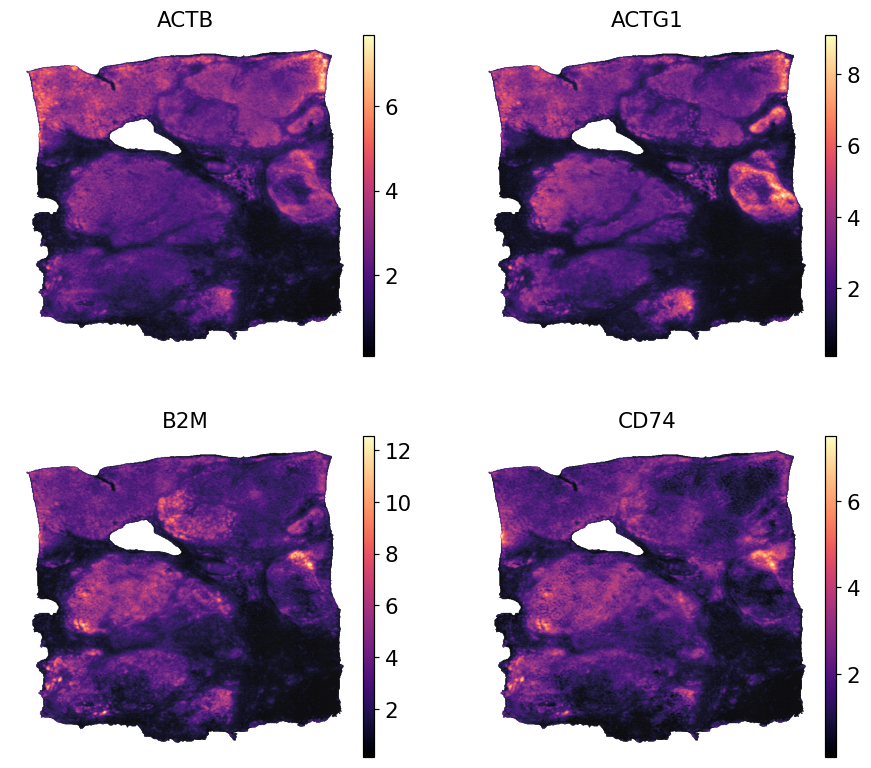

In [3]:
import scanpy as sc
sc.pl.embedding(pred, basis='spatial', color=list(pred.var_names[:4]),
                cmap='magma', s=1, ncols=2, frameon=False)

iStar's sub-spot grid is much denser than the 3,798 Visium spots of the original sample. The output AnnData can feed downstream spatial-domain detection (`ov.space.pySTAGATE`) and clustering to surface near-single-cell tissue niches.